In [1786]:
# !pip install plotly

# Carregando a base de dados

In [1787]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression                           
from sklearn.metrics import mean_absolute_error, r2_score 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from prophet import Prophet

In [1788]:
ibovespa = pd.read_csv(r"../data/trusted/ibovespa_historico.csv", sep=';')
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,alta,5.2109
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,baixa,5.2359
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,baixa,5.2196
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,baixa,5.2120
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,alta,5.1836


In [1789]:
# Quais os tipos informações compõe o banco de dados (base original)
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   data                 534 non-null    str    
 1   abertura             534 non-null    float64
 2   maxima               534 non-null    float64
 3   minima               534 non-null    float64
 4   fechamento           534 non-null    float64
 5   vol_reais            534 non-null    float64
 6   variacao_percentual  534 non-null    float64
 7   status               534 non-null    str    
 8   cotacao_dia_dolar    534 non-null    float64
dtypes: float64(7), str(2)
memory usage: 37.7 KB


# EDA - Análise Exploratória de Dados

In [1790]:
# Instanciando
le = LabelEncoder()
ibovespa["status_encoded"] = le.fit_transform(ibovespa["status"])

In [1791]:
ibovespa.describe()

,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,status_encoded
count,534.000000,534.000000,534.000000,534.000000,5.340000e+02,534.000000,534.000000,534.000000
mean,135.653060,136.561036,134.888457,135.754279,4.858124e+09,0.067959,5.473749,0.473783
std,13.813322,14.069473,13.746830,14.000180,4.948503e+09,0.916199,0.303307,0.499780
min,118.534000,119.451000,118.223000,118.533000,4.330000e+06,-4.310000,4.853900,0.000000
25%,127.223000,127.871250,126.448750,127.227500,9.370000e+06,-0.447500,5.300125,0.000000
50%,131.168000,131.867500,130.424000,131.168500,6.020000e+09,0.050000,5.472000,0.000000
75%,138.852250,139.396500,137.987500,138.879750,9.180000e+09,0.590000,5.674450,1.000000
max,189.694000,190.561000,186.959000,189.699000,2.487000e+10,3.330000,6.289600,1.000000


In [1792]:
# tamanho do meu dataframe
len(ibovespa)

534

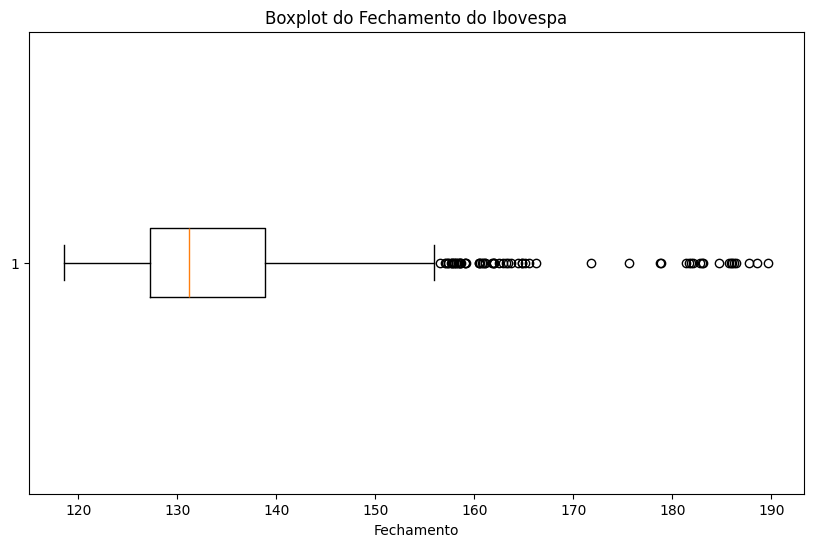

In [1793]:
plt.figure(figsize=(10, 6))
plt.boxplot(ibovespa['fechamento'], vert=False)
plt.title('Boxplot do Fechamento do Ibovespa')
plt.xlabel('Fechamento')
plt.show()

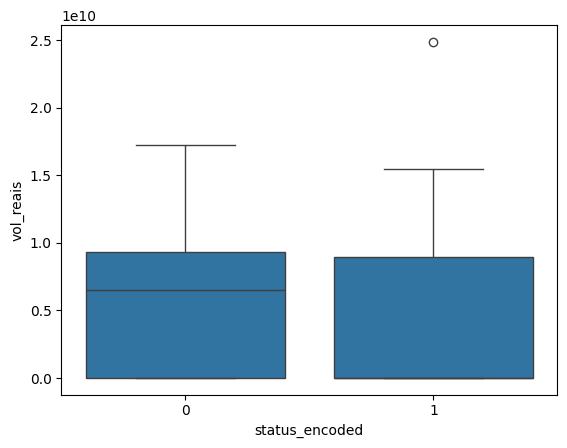

In [1794]:
sns.boxplot(x="status_encoded", y="vol_reais", data=ibovespa)
plt.show()

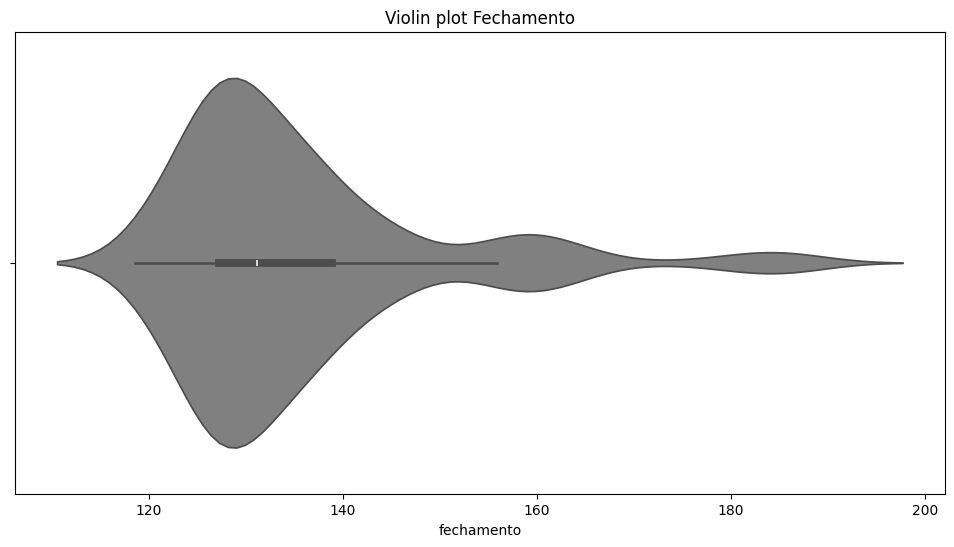

In [1795]:
#Criando o subplot do boxplot, para configurarmos o tamanho
fig, axes = plt.subplots(figsize=(12,6))
sns.violinplot(x="fechamento", data=ibovespa, color="gray")
axes.set_title('Violin plot Fechamento')
plt.show()

In [1796]:
# Transformando a coluna Data de objeto para data
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,alta,5.2109,0
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,baixa,5.2359,1
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,baixa,5.2196,1
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,baixa,5.2120,1
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,alta,5.1836,0


In [1797]:
# Quantidade de dados nulos por coluna
ibovespa.isnull().sum()

data                   0
abertura               0
maxima                 0
minima                 0
fechamento             0
vol_reais              0
variacao_percentual    0
status                 0
cotacao_dia_dolar      0
status_encoded         0
dtype: int64

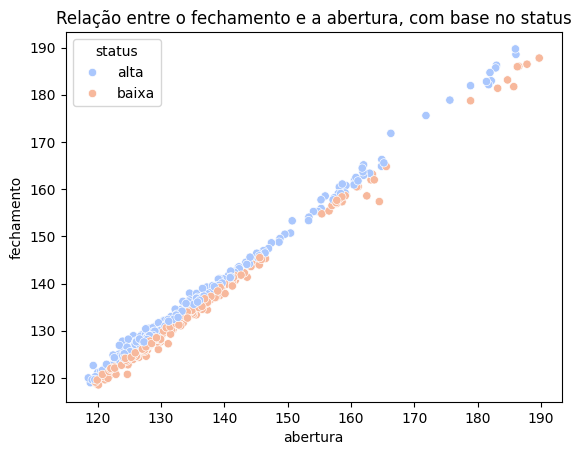

In [1798]:

#Vamos verificar ambas coluna gerando um gráfico de dispersão
sns.scatterplot(x='abertura', y='fechamento', hue='status', data=ibovespa, palette='coolwarm')
plt.xlabel('abertura')
plt.ylabel('fechamento')
plt.title('Relação entre o fechamento e a abertura, com base no status')
plt.show()

In [1799]:
# Validando a saída final da base
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 534 non-null    datetime64[us]
 1   abertura             534 non-null    float64       
 2   maxima               534 non-null    float64       
 3   minima               534 non-null    float64       
 4   fechamento           534 non-null    float64       
 5   vol_reais            534 non-null    float64       
 6   variacao_percentual  534 non-null    float64       
 7   status               534 non-null    str           
 8   cotacao_dia_dolar    534 non-null    float64       
 9   status_encoded       534 non-null    int64         
dtypes: datetime64[us](1), float64(7), int64(1), str(1)
memory usage: 41.8 KB


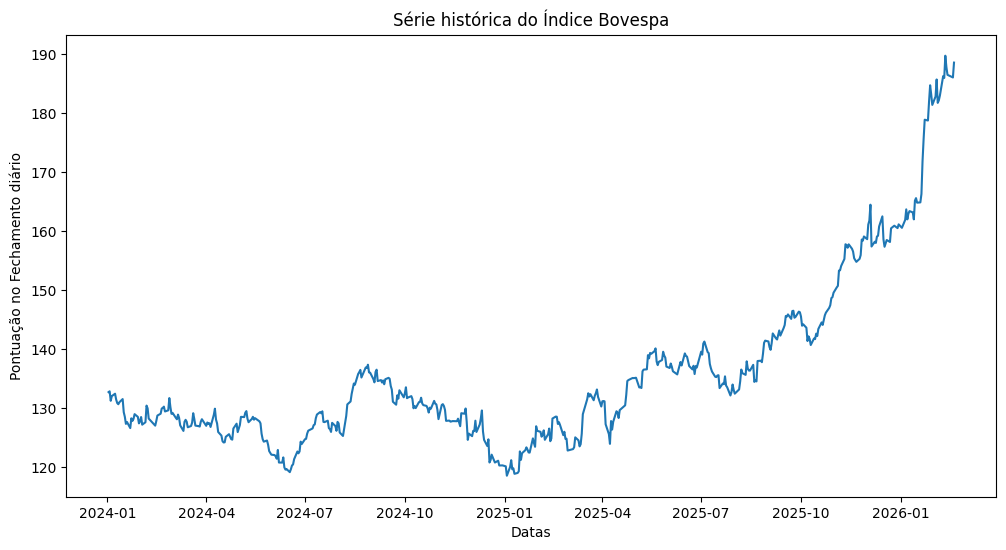

In [1800]:
# Análise temporal (série histórica)
plt.figure(figsize=(12, 6))
plt.plot(ibovespa["data"], ibovespa["fechamento"])
plt.xlabel("Datas")
plt.ylabel("Pontuação no Fechamento diário")
plt.title("Série histórica do Índice Bovespa")
plt.show()

In [1801]:
ibovespa = ibovespa.sort_values("data")

In [1802]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded
533,2024-01-02,134.186,134.195,132.095,132.697,8440000.0,-1.11,baixa,4.9235,1
532,2024-01-03,132.697,133.576,132.250,132.834,8700000.0,0.10,alta,4.9198,0
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0


## Testando o modelo SVC ❌

In [1803]:
# ibovespa["target_next"] = ibovespa["status_encoded"].shift(-1)

# ibovespa["fechamento_lag1"] = ibovespa["fechamento"].shift(1)
# ibovespa["vol_lag1"] = ibovespa["vol_log"].shift(1)
# ibovespa["dolar_lag1"] = ibovespa["cotacao_dia_dolar"].shift(1)

# ibovespa = ibovespa.dropna()

# X = ibovespa[[
#     "fechamento_lag1",
#     "vol_lag1",
#     "dolar_lag1"
# ]]

# y = ibovespa["target_next"]

In [1804]:
# model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
# ])

In [1805]:
# tscv = TimeSeriesSplit(n_splits=5)

In [1806]:
# for train_index, test_index in tscv.split(X):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)

#     acc = accuracy_score(y_test, y_pred)
#     print("Acurácia:", acc)

## Testando o modelo XGBoost ❌

In [1807]:
# # Ordenar por data
# ibovespa = ibovespa.sort_values("data")

# # Criar target corretamente
# ibovespa["target"] = (ibovespa["fechamento"].shift(-1) > ibovespa["fechamento"]).astype(int)

# # Remover última linha (que vira NaN)
# ibovespa = ibovespa.dropna()

In [1808]:

# X = ibovespa.drop(columns=[
#     "data",
#     "status",
#     "status_encoded",
#     "target",
#     "target_next",
#     "fechamento",
#     "variacao_percentual"
# ])

# y = ibovespa["target"]

# tscv = TimeSeriesSplit(n_splits=5)

# for train_index, test_index in tscv.split(X):
#     X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#     y_train, y_test = y.iloc[train_index], y.iloc[test_index]


# xgb = XGBClassifier(
#     objective="binary:logistic",
#     eval_metric="logloss",
#     use_label_encoder=False,
#     n_estimators=200,
#     learning_rate=0.02,
#     max_depth=3,
#     min_child_weight=3,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     gamma=0.1,
#     random_state=42
# )

# xgb.fit(X_train, y_train)

# y_pred = xgb.predict(X_test)

# print("Acurácia:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

## Testando o modelo LogisticRegression 🟢

In [1809]:
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa = ibovespa.sort_values("data")

ibovespa = ibovespa.dropna()

X = ibovespa.drop(columns=[
    "data",
    "vol_reais",
    "variacao_percentual",
    "status",
    "abertura",
    "cotacao_dia_dolar",
    "status_encoded",
])
y = ibovespa["status_encoded"]

X_train = X.iloc[:-30]
X_test = X.iloc[-30:] 

y_train = y.iloc[:-30]
y_test = y.iloc[-30:]

In [1810]:
X.head()

,maxima,minima,fechamento
533,134.195,132.095,132.697
532,133.576,132.250,132.834
531,132.885,131.024,131.226
530,132.635,130.579,132.023
529,132.498,131.015,132.427


In [1811]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.8333333333333334

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.81      0.94      0.87        18
           1       0.89      0.67      0.76        12

    accuracy                           0.83        30
   macro avg       0.85      0.81      0.82        30
weighted avg       0.84      0.83      0.83        30



In [1812]:
print("Acurácia treino:", accuracy_score(y_train, model.predict(X_train)))
print("Acurácia teste:", accuracy_score(y_test, model.predict(X_test)))

Acurácia treino: 0.7936507936507936
Acurácia teste: 0.8333333333333334


In [1813]:
y.value_counts(normalize=True)

status_encoded
0    0.526217
1    0.473783
Name: proportion, dtype: float64

In [1814]:
print(confusion_matrix(y_test, model.predict(X_test)))

[[17  1]
 [ 4  8]]


In [1815]:
# Teste de modelo para explosão de janelas de teste onde o modelo é treinado com os dados anteriores e testado com os dados seguintes, simulando um cenário real de previsão.

tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    scores.append(model.score(X_test, y_test))

print(scores)
print("Média:", np.mean(scores))

[0.7191011235955056, 0.7865168539325843, 0.7865168539325843, 0.7303370786516854, 0.8089887640449438]
Média: 0.7662921348314609


In [1816]:
## Resultado da Analise:

# Treino 79% / Teste 83% → consistente

# Classes balanceadas -> sem viés

# Matriz de confusão está saudável

## Testando o modelo KNN  ❌

In [1817]:
# ibovespa.head()

In [1818]:
# ibovespa["data"] = pd.to_datetime(ibovespa["data"])
# ibovespa = ibovespa.sort_values("data")

# ibovespa = ibovespa.dropna()

# X = ibovespa.drop(columns=[
#     "data",
#     "vol_reais",
#     "variacao_percentual",
#     "status",
#     "cotacao_dia_dolar",
#     "status_encoded",
# ])
# y = ibovespa["status_encoded"]

# X_train = X.iloc[:-30]
# X_test = X.iloc[-30:] 

# y_train = y.iloc[:-30]
# y_test = y.iloc[-30:]

Testando o melhor neighbors K

In [1819]:
# K = 0

# for k in range(1, 21):
#     pipeline = Pipeline([
#         ("scaler", StandardScaler()),
#         ("knn", KNeighborsClassifier(n_neighbors=k,))
#     ])
#     pipeline.fit(X_train, y_train)
#     acc = accuracy_score(y_test, pipeline.predict(X_test))
#     # K = k
#     K = k
#     print(k, acc)

In [1820]:
# # Testando o modelo com k=3, para verificar a acurácia
# pipeline = Pipeline([
#         ("scaler", StandardScaler()),
#         ("knn", KNeighborsClassifier(n_neighbors=K))
#     ])
# pipeline.fit(X_train, y_train)
# acc = accuracy_score(y_test, pipeline.predict(X_test))
# print("Vizinhos: {0}".format(K), "Acurácia:", acc)

# Testando o modelo Regressao Linear Minimo Escalado ❌

In [1821]:
# X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
# y = ibovespa["status_encoded"]

# X_train = X.iloc[:-30]
# X_test  = X.iloc[-30:]

# y_train = y.iloc[:-30]
# y_test  = y.iloc[-30:]

# scaler = MinMaxScaler()

# scaler.fit(X_train)

# x_train_scaled = scaler.transform(X_train)
# x_test_scaled = scaler.transform(X_test)

In [1822]:
# model = LinearRegression()
# model.fit(x_train_scaled, y_train)

In [1823]:
# # Fazendo as previsões
# y_pred = model.predict(x_test_scaled)

In [1824]:
# # Avaliando o modelo
# MAE = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print('MAE',MAE)
# print('r²',r2)

# Testando o modelo Regressao Linear ❌

In [1825]:
## ESSE MODELO QUANDO COLOCAMOS APENAS 30 DIAS DE TESTE ELE INFELIZMENTE NÃO FUNCIONA, SUA ACURACIA CAI PARA 0.61
# ibovespa.head()

In [1826]:
# X = ibovespa.drop(columns=[
#     "data",
#     "vol_reais",
#     "variacao_percentual",
#     "status",
#     "cotacao_dia_dolar",
#     "status_encoded",
# ])
# y = ibovespa["status_encoded"]

# X_train = X.iloc[:-30]
# X_test  = X.iloc[-30:]

# y_train = y.iloc[:-30]
# y_test  = y.iloc[-30:]

In [1827]:
# model = LinearRegression()
# model.fit(X_train, y_train)

In [1828]:
# y_pred = model.predict(X_test)
# r_sq = model.score(X, y)

# print('Coeficiente de Determinação (R²):', r_sq)

In [1829]:
# print('Intercepto:', model.intercept_)

# Testando o modelo RandomForestClassifier ❌

In [1830]:
## ESSE MODELO QUANDO COLOCAMOS APENAS 30 DIAS DE TESTE ELE INFELIZMENTE NÃO FUNCIONA, SUA ACURACIA CAI PARA 0.6

# ibovespa.head()

In [1831]:
# ibovespa["data"] = pd.to_datetime(ibovespa["data"])
# ibovespa = ibovespa.sort_values("data")

# ibovespa = ibovespa.dropna()

# X = ibovespa.drop(columns=[
#     "data",
#     "vol_reais",
#     "variacao_percentual",
#     "status",
#     "cotacao_dia_dolar",
#     "status_encoded",
# ])
# y = ibovespa["status_encoded"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# model = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=8,
#     random_state=42
# )

# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# acc = accuracy_score(y_test, y_pred)

# print("Acurácia:", acc)
# print("\nRelatório:")
# print(classification_report(y_test, y_pred))


In [1832]:
# # Acurácia treino
# y_train_pred = model.predict(X_train)
# train_acc = accuracy_score(y_train, y_train_pred)

# # Acurácia teste
# test_acc = accuracy_score(y_test, y_pred)

# print("Acurácia Treino:", train_acc)
# print("Acurácia Teste:", test_acc)

# Testando o Modelo TimeSeries ⚠️

Talvez não usariamos porque seu resultado está mais contido em uma serie temporal futura indicando uma direção do que de fato uma direção Alta ou Baixa na Ibovespa

In [1833]:
# ibovespa.rename(columns={"data": "ds", "fechamento": "y"}, inplace=True)
# ibovespa.head()

In [1834]:


# m = Prophet()
# m.fit(ibovespa[["ds", "y"]])

# # Separação temporal
# train = ibovespa.iloc[:-30]
# test  = ibovespa.iloc[-30:]

# future = m.make_future_dataframe(periods=5)
# future.tail()

# forecast = m.predict(future)
# forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

# fig1 = m.plot(forecast)
# plt.title("Previsão do Fechamento do Ibovespa")

# # Pegar apenas previsão dos últimos 30 dias
# forecast_test = forecast[['ds','yhat']].iloc[-30:]

# test = test.reset_index(drop=True)
# forecast_test = forecast_test.reset_index(drop=True)

# # Métricas
# mae = mean_absolute_error(test['y'], forecast_test['yhat'])
# rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))
# mape = np.mean(np.abs((test['y'] - forecast_test['yhat']) / test['y'])) * 100

# print("MAE:", mae)
# print("RMSE:", rmse)
# print("MAPE:", mape)

